<a href="https://colab.research.google.com/github/negilbabu/Heart-Disease-Prediction-Ai-/blob/dev/HeartDiseasePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!apt-get update
!apt-get install git

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/abdelDebug/Heart-Disease-Data/refs/heads/main/heart_disease.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [7]:
df.shape

(303, 14)

In [8]:
df["target"].unique()

array([0, 1])

In [9]:
df.columns = df.columns.str.strip()

In [10]:
print("Checking for null values....")
count = df.isnull().sum()
for col, null_count in count.items():
    if null_count > 0:
        print(f"Column '{col}' has {null_count} null values. Removing null values...")
        df = df.dropna(subset=[col])

    else:
        print(f"Column '{col}' has no null values.")
print("Shape of dataframe", df.shape)

Checking for null values....
Column 'age' has no null values.
Column 'sex' has no null values.
Column 'cp' has no null values.
Column 'trestbps' has no null values.
Column 'chol' has no null values.
Column 'fbs' has no null values.
Column 'restecg' has no null values.
Column 'thalach' has no null values.
Column 'exang' has no null values.
Column 'oldpeak' has no null values.
Column 'slope' has no null values.
Column 'ca' has no null values.
Column 'thal' has no null values.
Column 'target' has no null values.
Shape of dataframe (303, 14)


In [11]:
print("Checking for duplicated rows:")
duplicated_rows = df.duplicated()
print(f"Total duplicated rows: {duplicated_rows.sum()}")

if duplicated_rows.any():
    df_removed_duplicates = df.drop_duplicates()
    print("Shape of dataframe after removing duplicates", df_removed_duplicates.shape)

Checking for duplicated rows:
Total duplicated rows: 0


Exploratory Data Analysis

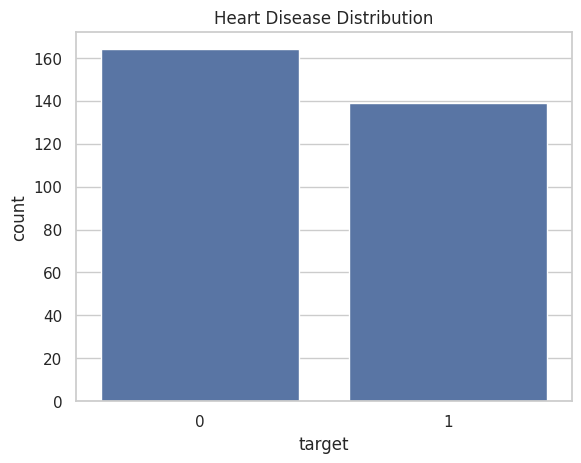

In [12]:
sns.set(style="whitegrid")

sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution')

plt.show()

People with heart disease are less than those without heart disease

<Axes: xlabel='age', ylabel='Count'>

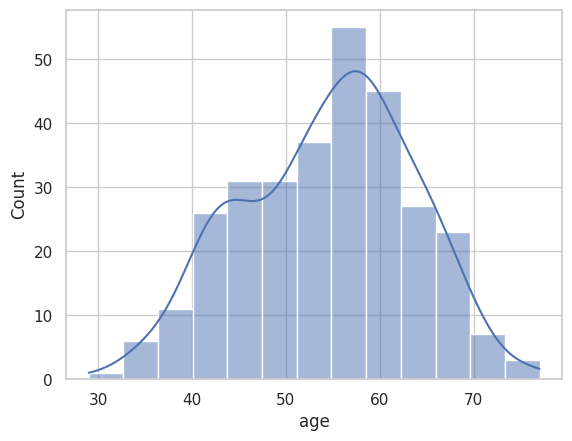

In [13]:
sns.histplot(df['age'], kde=True)

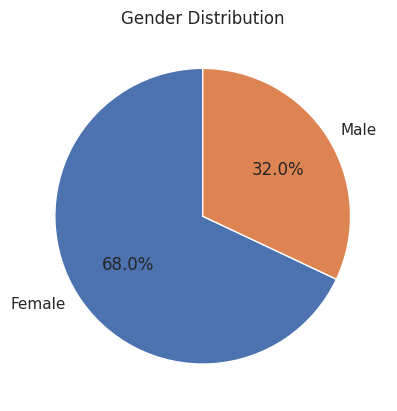

In [14]:
# Mapping gender values to labels
gender_mapping = {0: 'Male', 1: 'Female'}
df_mapped = df.copy()
df_mapped['Gender'] = df_mapped['sex'].map(gender_mapping)

gender_counts = df_mapped['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.show()

Pie chart shows that number of females are more in the dataset than men.

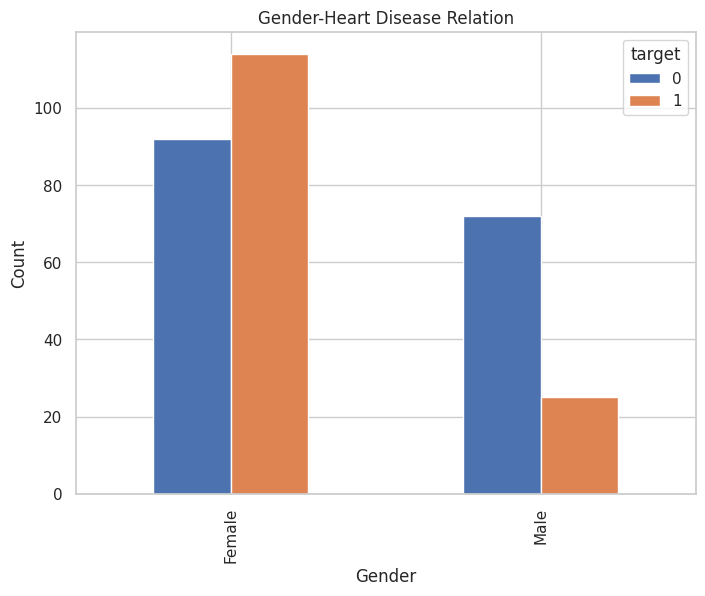

In [15]:
gender_disease_relation = df_mapped.groupby(['Gender', 'target'])['target'].count().unstack()
gender_disease_relation.plot(kind='bar', stacked=False, figsize=(8,6))
plt.title('Gender-Heart Disease Relation')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Plot shows that heart diseases are more often in females when comparing to male

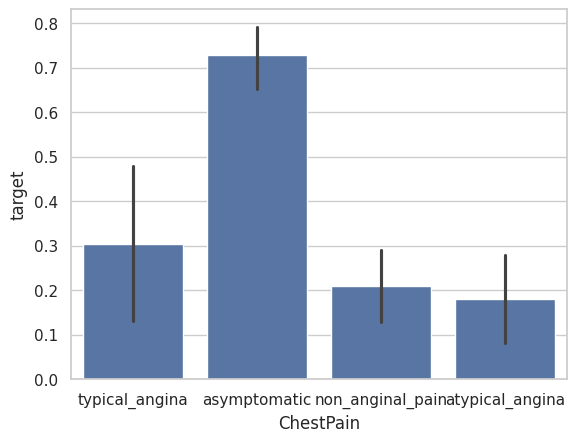

<Figure size 600x1500 with 0 Axes>

In [16]:
# Mapping ChestPain values to labels
cp_mapping = {0: 'typical_angina', 1: 'atypical_angina', 2: 'non_anginal_pain', 3: 'asymptomatic'}
df_mapped['ChestPain'] = df_mapped['cp'].map(cp_mapping)
sns.barplot(x="ChestPain", y="target", data=df_mapped)
plt.figure(figsize=(6, 15))
plt.show()


This barplot depicts that the people with asymptomatic chest pain has the higher chances of having a heart disease while comparing with others.


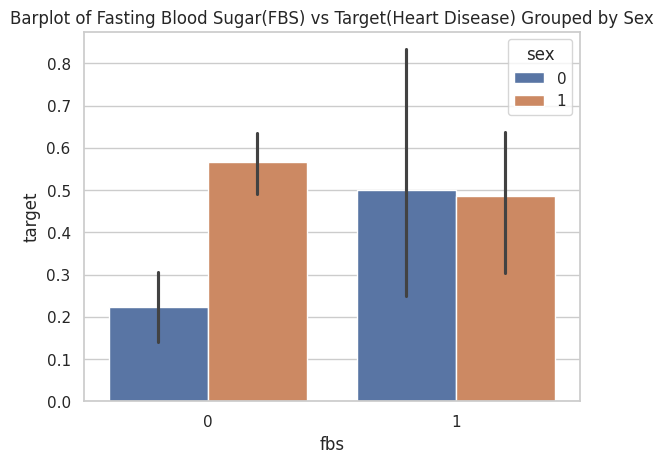

In [19]:
sns.barplot(x='fbs', y='target', hue='sex', data=df)
plt.title("Barplot of Fasting Blood Sugar(FBS) vs Target(Heart Disease) Grouped by Sex")

plt.show()

Individuals having Fasting blood pressure is almost similar for male and female.

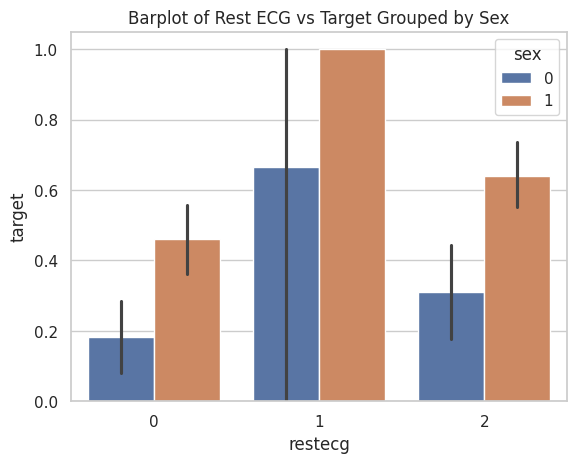

In [23]:
sns.barplot(x='restecg', y='target', hue='sex', data=df)
plt.title("Barplot of Rest ECG vs Target Grouped by Sex")

plt.show()



*   Restecg values 1(Having ST-T wave abnormality) and 2(Showing probable or definite left ventricular hypertrophy) having more heart diseases.
*   Also, female patients having high restecg values.

